In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import math

[*********************100%***********************]  1 of 1 completed


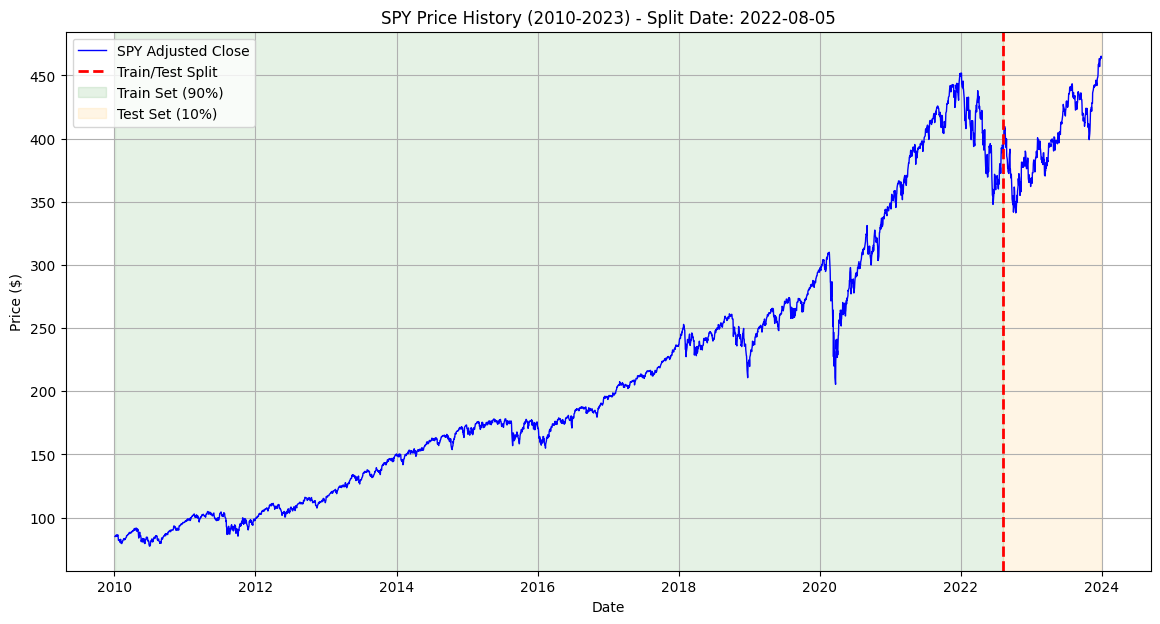

Total Trading Days: 3522
Train Set Size: 3169
Test Set Size: 353


In [2]:
print("Downloading SPY data...")
data = yf.download('SPY', start='2010-01-01', end='2023-12-31', auto_adjust=False)

prices = data['Adj Close']

prices = prices.ffill()
prices = prices.dropna()

split_idx = int(len(prices) * 0.90)
split_date = prices.index[split_idx]

plt.figure(figsize=(14, 7))

plt.plot(prices.index, prices, label='SPY Adjusted Close', color='blue', linewidth=1)

plt.axvline(x=split_date, color='red', linestyle='--', linewidth=2, label='Train/Test Split')

plt.axvspan(prices.index[0], split_date, color='green', alpha=0.1, label='Train Set (90%)')
plt.axvspan(split_date, prices.index[-1], color='orange', alpha=0.1, label='Test Set (10%)')

plt.title(f'SPY Price History (2010-2023) - Split Date: {split_date.date()}')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Total Trading Days: {len(prices)}")
print(f"Train Set Size: {split_idx}")
print(f"Test Set Size: {len(prices) - split_idx}")

In [3]:
# ---------------------------------------------------------
# STEP 2: Data Cleaning & Statistics (Using existing 'data')
# ---------------------------------------------------------

# 1. Prepare 'prices' Series from the existing 'data' variable
# We handle potential MultiIndex issues from yfinance
if isinstance(data.columns, pd.MultiIndex):
    # If columns are like ('Adj Close', 'SPY'), extract just the numbers
    prices = data.xs('Adj Close', axis=1, level=0)
    if isinstance(prices, pd.DataFrame):
        prices = prices.iloc[:, 0] # Take the first column if still a DF
else:
    prices = data['Adj Close']

# Ensure it's a Series (1D array), not a DataFrame (table)
prices = prices.squeeze()

# ---------------------------------------------------------
# A. Handling Missing Values
# ---------------------------------------------------------
initial_count = len(prices)
missing_count_raw = prices.isnull().sum()

# Forward fill missing values, then drop remaining NaNs
prices_clean = prices.ffill().dropna()

# ---------------------------------------------------------
# B. Removing "Bug" Outliers
# ---------------------------------------------------------

# 1. Remove non-positive prices (<= 0)
prices_clean = prices_clean[prices_clean > 0]

# 2. Remove Extreme Daily Returns (Potential Data Bugs)
# Calculate daily percent change
daily_returns = prices_clean.pct_change()

# Threshold: 20% move in a single day (likely a bug for SPY)
BUG_THRESHOLD = 0.20
valid_dates = daily_returns[abs(daily_returns) < BUG_THRESHOLD].index

# Keep the first day (NaN return) + valid days
prices_final = prices_clean.loc[prices_clean.index.isin(valid_dates) | (prices_clean.index == prices_clean.index[0])]

final_count = len(prices_final)
removed_count = initial_count - final_count

# ---------------------------------------------------------
# C. Statistics Report
# ---------------------------------------------------------
print("-" * 40)
print("DATA CLEANING REPORT")
print("-" * 40)
print(f"Total Initial Days:   {initial_count}")
print(f"Missing Values Found: {missing_count_raw}")
print(f"Rows Removed (Bugs):  {removed_count}")
print(f"Final Valid Days:     {final_count}")
print("-" * 40)
print("STATISTICS (On Cleaned Data)")
print("-" * 40)

# Convert stats to standard python floats to avoid printing errors
mean_val = float(prices_final.mean())
var_val = float(prices_final.var())
std_val = float(prices_final.std())
min_val = float(prices_final.min())
max_val = float(prices_final.max())

print(f"Mean Price:       {mean_val:.4f}")
print(f"Variance:         {var_val:.4f}")
print(f"Std Deviation:    {std_val:.4f}")
print(f"Min Price:        {min_val:.4f}")
print(f"Max Price:        {max_val:.4f}")
print("-" * 40)

----------------------------------------
DATA CLEANING REPORT
----------------------------------------
Total Initial Days:   3522
Missing Values Found: 0
Rows Removed (Bugs):  0
Final Valid Days:     3522
----------------------------------------
STATISTICS (On Cleaned Data)
----------------------------------------
Mean Price:       225.3915
Variance:         12185.0536
Std Deviation:    110.3859
Min Price:        77.3595
Max Price:        465.1900
----------------------------------------


----------------------------------------
PREPROCESSING STATS
----------------------------------------
Train Mean used: 0.000485
Train Std used:  0.010975
Train Windows Created: (3104, 64)
Test Windows Created:  (289, 64)


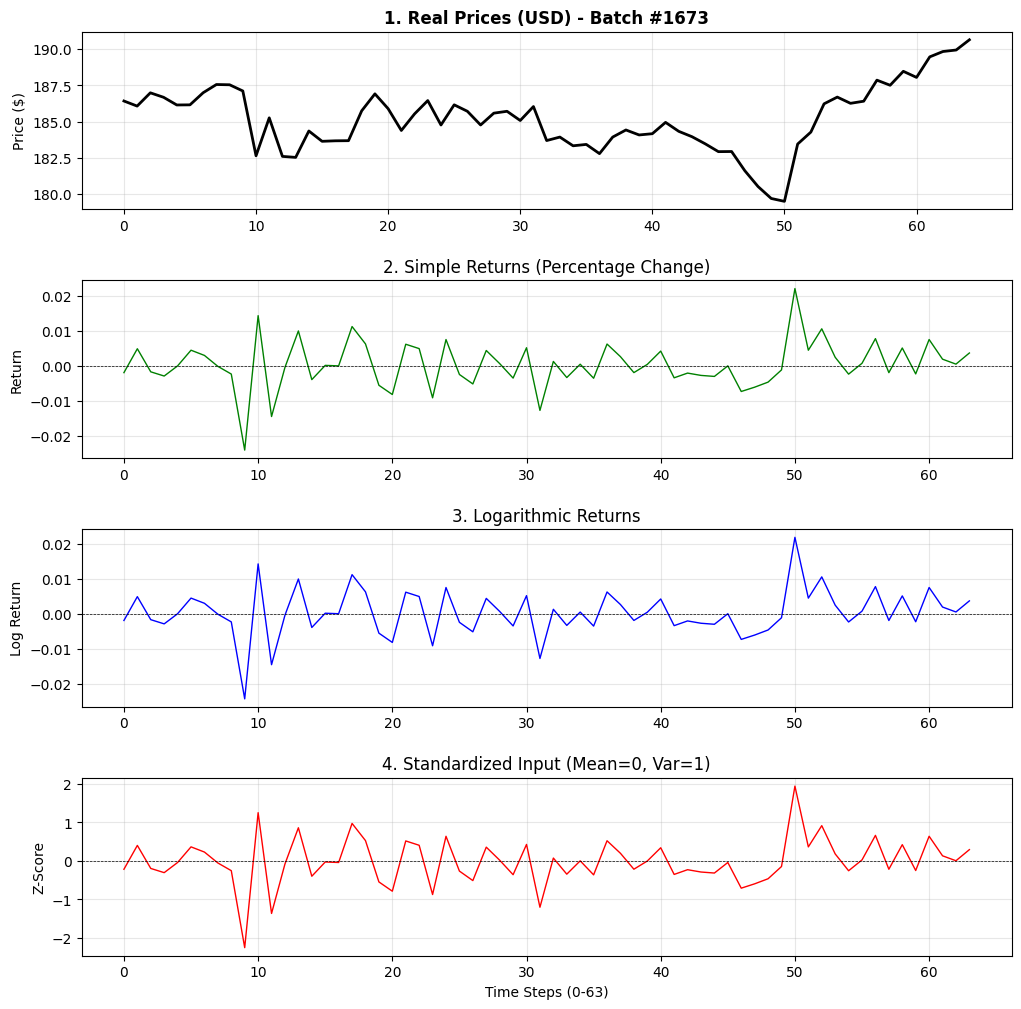

In [4]:
# ---------------------------------------------------------
# STEP 3: Preprocessing, Windowing & Visualization
# ---------------------------------------------------------

# 1. Calculate Log Returns
# Formula: ln(P_t / P_{t-1})
# Note: This reduces the array length by 1
log_returns = np.log(prices_final / prices_final.shift(1)).dropna()

# 2. Chronological Train/Test Split
# We split BEFORE windowing to prevent data leakage
split_idx = int(len(log_returns) * 0.90)

train_logs = log_returns.iloc[:split_idx]
test_logs = log_returns.iloc[split_idx:]

# 3. Global Standardization (Fit on Train, Transform All)
train_mean = train_logs.mean()
train_std = train_logs.std()

# Standardize
train_norm = (train_logs - train_mean) / train_std
test_norm = (test_logs - train_mean) / train_std

print("-" * 40)
print("PREPROCESSING STATS")
print("-" * 40)
print(f"Train Mean used: {train_mean:.6f}")
print(f"Train Std used:  {train_std:.6f}")

# ---------------------------------------------------------
# 4. Create Sliding Windows (Batches)
# ---------------------------------------------------------
def create_windows(data_series, window_size=64):
    """
    Converts a 1D series into a 2D array of windows.
    Output Shape: (num_samples, window_size)
    """
    # Convert to numpy for efficiency
    data_np = data_series.values

    # List to store windows
    windows = []

    # Iterate with a sliding window
    for i in range(len(data_np) - window_size):
        window = data_np[i : i + window_size]
        windows.append(window)

    return np.array(windows)

WINDOW_SIZE = 64
train_windows = create_windows(train_norm, WINDOW_SIZE)
test_windows = create_windows(test_norm, WINDOW_SIZE)

print(f"Train Windows Created: {train_windows.shape}")
print(f"Test Windows Created:  {test_windows.shape}")

# ---------------------------------------------------------
# 5. Visualize a Random Batch
# ---------------------------------------------------------

# Pick a random index from the training set
random_idx = np.random.randint(0, len(train_windows))
batch_data_std = train_windows[random_idx]

# Recover original data for plotting
# 1. Destandardize -> Log Returns
batch_log_returns = (batch_data_std * train_std) + train_mean

# 2. Reconstruct Prices (We need to find the exact start index in prices_final)
# log_returns starts from index 1 of prices_final
# train_windows[random_idx] corresponds to log_returns[random_idx : random_idx + 64]
# This corresponds to price changes from prices_final[random_idx] to prices_final[random_idx + 64]
start_price_idx = random_idx
end_price_idx = random_idx + WINDOW_SIZE + 1 # +1 because we need N+1 prices for N returns

batch_prices = prices_final.iloc[start_price_idx : end_price_idx]

# 3. Simple Returns (Percentage Change)
batch_simple_returns = batch_prices.pct_change().dropna()

# ---------------------------------------------------------
# Plotting
# ---------------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=False)
plt.subplots_adjust(hspace=0.4)

# Plot 1: Real Prices ($)
axes[0].plot(batch_prices.values, color='black', linewidth=2)
axes[0].set_title(f"1. Real Prices (USD) - Batch #{random_idx}", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Price ($)")
axes[0].grid(True, alpha=0.3)

# Plot 2: Simple Returns (%)
axes[1].plot(batch_simple_returns.values, color='green', linewidth=1)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.5)
axes[1].set_title("2. Simple Returns (Percentage Change)", fontsize=12)
axes[1].set_ylabel("Return")
axes[1].grid(True, alpha=0.3)

# Plot 3: Log Returns
axes[2].plot(batch_log_returns, color='blue', linewidth=1)
axes[2].axhline(0, color='black', linestyle='--', linewidth=0.5)
axes[2].set_title("3. Logarithmic Returns", fontsize=12)
axes[2].set_ylabel("Log Return")
axes[2].grid(True, alpha=0.3)

# Plot 4: Standardized Log Returns (Network Input)
axes[3].plot(batch_data_std, color='red', linewidth=1)
axes[3].axhline(0, color='black', linestyle='--', linewidth=0.5)
axes[3].set_title(f"4. Standardized Input (Mean=0, Var=1)", fontsize=12)
axes[3].set_ylabel("Z-Score")
axes[3].set_xlabel("Time Steps (0-63)")
axes[3].grid(True, alpha=0.3)

plt.show()

Generating Offline Data... (Factor: 4x)
----------------------------------------
Original Train Size:  (3104, 64)
Augmented Train Size: (12416, 64)
----------------------------------------


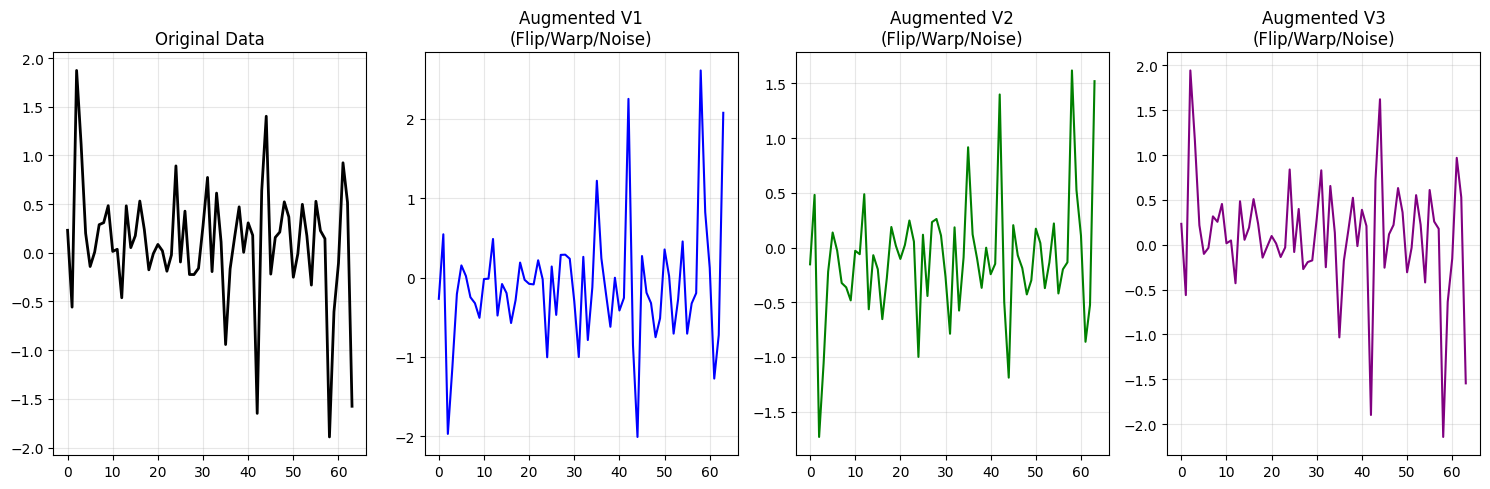

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import random

# ---------------------------------------------------------
# 1. Helper Functions (Adaptive & Warping)
# ---------------------------------------------------------
def generate_magnitude_warp(length, sigma=0.1, num_knots=4):
    """
    Generates a smooth curve oscillating around 1.0.
    """
    xx = np.linspace(0, length, num_knots)
    yy = np.random.normal(loc=1.0, scale=sigma, size=num_knots)

    cs = CubicSpline(xx, yy)
    x_range = np.arange(length)
    return cs(x_range)

def augment_offline(original_data, expansion_factor=4):
    """
    Expands the dataset by creating copies with specific augmentations.
    Uses Adaptive Noise based on local volatility.
    """
    augmented_list = []

    print(f"Generating Offline Data... (Factor: {expansion_factor}x)")

    for sample in original_data:
        # 1. Always keep the ORIGINAL
        augmented_list.append(sample)

        # Calculate Local Volatility (Standard Deviation of THIS window)
        local_std = np.std(sample)
        if local_std < 1e-6: local_std = 1.0 # Prevent zero division for flat lines

        # 2. Generate (expansion_factor - 1) augmented versions
        for _ in range(expansion_factor - 1):
            new_sample = sample.copy()

            # --- Decision Tree for Augmentation ---
            # We mix and match approved techniques randomly

            # A. Vertical Flip (50% chance)
            if random.random() > 0.5:
                new_sample = -new_sample

            # B. Magnitude Warping (Multiplicative - naturally adaptive)
            # Since it multiplies (e.g., * 1.1), it respects the scale automatically.
            if random.random() > 0.3: # 70% chance
                warp_curve = generate_magnitude_warp(len(sample), sigma=0.1) # Sigma determines warp intensity
                new_sample = new_sample * warp_curve

            # C. Random Scaling (Constant)
            scale = random.uniform(0.85, 1.15)
            new_sample = new_sample * scale

            # D. Adaptive Gaussian Noise (Additive)
            # Key Fix: Noise is proportional to Local STD (e.g., 5% of local volatility)
            noise_intensity = 0.05 * local_std
            noise = np.random.normal(0, noise_intensity, size=new_sample.shape)
            new_sample = new_sample + noise

            augmented_list.append(new_sample)

    return np.array(augmented_list)

# ---------------------------------------------------------
# 2. Execute Augmentation
# ---------------------------------------------------------
# Assuming 'train_windows' exists as numpy array from previous steps
# We only augment Training data!
x_train_augmented = augment_offline(train_windows, expansion_factor=4)

# Test data remains untouched
x_test_final = test_windows

print("-" * 40)
print(f"Original Train Size:  {train_windows.shape}")
print(f"Augmented Train Size: {x_train_augmented.shape}")
print("-" * 40)

# ---------------------------------------------------------
# 3. Visualization (Quality Check)
# ---------------------------------------------------------
# Pick a random original index
# Since data is structured as [Org, Aug1, Aug2, Aug3, Org, Aug1...],
# we pick an index divisible by 4 to get an original.
idx = np.random.randint(0, len(train_windows)) * 4

plt.figure(figsize=(15, 5))

# Plot Original
plt.subplot(1, 4, 1)
plt.plot(x_train_augmented[idx], color='black', linewidth=2)
plt.title("Original Data")
plt.grid(True, alpha=0.3)

# Plot Augment 1
plt.subplot(1, 4, 2)
plt.plot(x_train_augmented[idx+1], color='blue')
plt.title("Augmented V1\n(Flip/Warp/Noise)")
plt.grid(True, alpha=0.3)

# Plot Augment 2
plt.subplot(1, 4, 3)
plt.plot(x_train_augmented[idx+2], color='green')
plt.title("Augmented V2\n(Flip/Warp/Noise)")
plt.grid(True, alpha=0.3)

# Plot Augment 3
plt.subplot(1, 4, 4)
plt.plot(x_train_augmented[idx+3], color='purple')
plt.title("Augmented V3\n(Flip/Warp/Noise)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [50]:
import torch
import torch.nn as nn
import numpy as np

# ---------------------------------------------------------
# A. Lightweight ResBlock (No Time Injection Logic)
# ---------------------------------------------------------
class ResBlock(nn.Module):
    """
    Simplified Conv Block.
    Time is NOT injected here anymore. It is part of the input channels.
    """
    def __init__(self, in_channels, out_channels, dropout=0.3):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(4, out_channels), # Small groups for small batch/channels
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.conv2 = nn.Sequential(
            nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(4, out_channels),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        # Residual Link
        self.residual_conv = nn.Identity()
        if in_channels != out_channels:
            self.residual_conv = nn.Conv1d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        h = self.conv1(x)
        h = self.conv2(h)
        return h + self.residual_conv(x)

# ---------------------------------------------------------
# B. Main U-Net Architecture (Time as Channel)
# ---------------------------------------------------------
class FinanceUNet1D(nn.Module):
    def __init__(self, input_dim=64, base_channels=16, dropout=0.3):
        super().__init__()

        # Note: Input channels = 2 (1 for Data + 1 for Time)
        self.init_conv = nn.Conv1d(2, base_channels, kernel_size=3, padding=1)

        # --- ENCODER ---
        self.down1 = ResBlock(base_channels, base_channels, dropout)
        self.pool1 = nn.Conv1d(base_channels, base_channels, kernel_size=3, stride=2, padding=1)

        self.down2 = ResBlock(base_channels, base_channels*2, dropout)
        self.pool2 = nn.Conv1d(base_channels*2, base_channels*2, kernel_size=3, stride=2, padding=1)

        self.down3 = ResBlock(base_channels*2, base_channels*4, dropout)
        self.pool3 = nn.Conv1d(base_channels*4, base_channels*4, kernel_size=3, stride=2, padding=1)

        # --- BOTTLENECK ---
        self.bottleneck = ResBlock(base_channels*4, base_channels*4, dropout)

        # --- DECODER ---
        self.up1 = nn.ConvTranspose1d(base_channels*4, base_channels*2, kernel_size=4, stride=2, padding=1)
        self.conv_up1 = ResBlock(base_channels*2 + base_channels*4, base_channels*2, dropout)

        self.up2 = nn.ConvTranspose1d(base_channels*2, base_channels, kernel_size=4, stride=2, padding=1)
        self.conv_up2 = ResBlock(base_channels + base_channels*2, base_channels, dropout)

        self.up3 = nn.ConvTranspose1d(base_channels, base_channels, kernel_size=4, stride=2, padding=1)
        self.conv_up3 = ResBlock(base_channels + base_channels, base_channels, dropout)

        # Final Projection
        self.final_conv = nn.Conv1d(base_channels, 1, kernel_size=1)

    def forward(self, x, t):
        # x: (Batch, 64)
        # t: (Batch) or (Batch, 1)

        # 1. Prepare Data Channel
        x = x.unsqueeze(1) # (Batch, 1, 64)

        # 2. Prepare Time Channel
        if t.dim() == 1: t = t.unsqueeze(-1) # (Batch, 1)
        # Expand time to match sequence length: (Batch, 1, 64)
        t_channel = t.unsqueeze(-1).expand(-1, -1, x.shape[-1])

        # 3. Concatenate: (Batch, 2, 64)
        x_in = torch.cat([x, t_channel], dim=1)

        # --- Encoder ---
        x = self.init_conv(x_in)

        x1 = self.down1(x)
        x = self.pool1(x1)

        x2 = self.down2(x)
        x = self.pool2(x2)

        x3 = self.down3(x)
        x = self.pool3(x3)

        # --- Bottleneck ---
        x = self.bottleneck(x)

        # --- Decoder ---
        x = self.up1(x)
        x = torch.cat([x, x3], dim=1)
        x = self.conv_up1(x)

        x = self.up2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.conv_up2(x)

        x = self.up3(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv_up3(x)

        out = self.final_conv(x)
        return out.squeeze(1)

# Initialize Model (Ultra Light)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FinanceUNet1D(input_dim=64, base_channels=16, dropout=0.3).to(DEVICE)

# Print Stats
print("="*60)
print("ULTRA-LIGHT MODEL ARCHITECTURE (Time Channel Strategy)")
print(model)
print("="*60)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {total_params:,}")
print("="*60)

# Test Forward Pass (Dummy Data)
print("\nPerforming Dummy Forward Pass...")
dummy_x = torch.randn(8, 64).to(DEVICE)  # Batch of 8
dummy_t = torch.rand(8).to(DEVICE)       # Random times

try:
    output = model(dummy_x, dummy_t)
    print(f"Input Shape:  {dummy_x.shape}")
    print(f"Output Shape: {output.shape}")
    if output.shape == dummy_x.shape:
        print("✅ SUCCESS: Output shape matches Input shape.")
    else:
        print("❌ ERROR: Shape mismatch!")
except Exception as e:
    print(f"❌ ERROR during forward pass: {e}")

ULTRA-LIGHT MODEL ARCHITECTURE (Time Channel Strategy)
FinanceUNet1D(
  (init_conv): Conv1d(2, 16, kernel_size=(3,), stride=(1,), padding=(1,))
  (down1): ResBlock(
    (conv1): Sequential(
      (0): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): GroupNorm(4, 16, eps=1e-05, affine=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.3, inplace=False)
    )
    (conv2): Sequential(
      (0): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): GroupNorm(4, 16, eps=1e-05, affine=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.3, inplace=False)
    )
    (residual_conv): Identity()
  )
  (pool1): Conv1d(16, 16, kernel_size=(3,), stride=(2,), padding=(1,))
  (down2): ResBlock(
    (conv1): Sequential(
      (0): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): GroupNorm(4, 32, eps=1e-05, affine=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.3, inplace=False)
    )
    (conv2): S

In [51]:
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# ---------------------------------------------------------
# 1. Setup DataLoaders
# ---------------------------------------------------------
# Assuming x_train_augmented and x_test_final are available from previous steps
BATCH_SIZE = 64
tensor_x_train = torch.tensor(x_train_augmented, dtype=torch.float32)
tensor_x_test = torch.tensor(x_test_final, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(tensor_x_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(tensor_x_test), batch_size=BATCH_SIZE, shuffle=False)

print(f"Data Loaded: {len(train_loader.dataset)} Training samples, {len(test_loader.dataset)} Test samples.")

# ---------------------------------------------------------
# 2. Hyperparameters & Optimizer
# ---------------------------------------------------------
LEARNING_RATE = 1e-3
EPOCHS = 150
PATIENCE_LR = 5
FACTOR_LR = 0.5
PATIENCE_STOP = 20

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
loss_fn = nn.MSELoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=FACTOR_LR, patience=PATIENCE_LR
)

# ---------------------------------------------------------
# 3. Training Loop
# ---------------------------------------------------------
train_loss_history = []
val_loss_history = []
best_val_loss = float('inf')
early_stop_counter = 0

print("\nStarting Training...")
print("=" * 85)
print(f"{'Epoch':<10} | {'Train Loss':<12} | {'Val Loss':<12} | {'Status / LR Update'}")
print("-" * 85)

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    batch_losses = []

    for batch in train_loader:
        x_1 = batch[0].to(DEVICE)
        bs = x_1.shape[0]

        # Flow Matching Setup
        x_0 = torch.randn_like(x_1).to(DEVICE)
        t = torch.rand(bs, 1).to(DEVICE)

        # Interpolation
        x_t = (1 - t) * x_0 + t * x_1
        target_v = x_1 - x_0

        # Forward & Backward
        pred_v = model(x_t, t)
        loss = loss_fn(pred_v, target_v)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        batch_losses.append(loss.item())

    avg_train_loss = np.mean(batch_losses)
    train_loss_history.append(avg_train_loss)

    # --- VALIDATION ---
    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for batch in test_loader:
            x_1_val = batch[0].to(DEVICE)
            bs = x_1_val.shape[0]
            x_0_val = torch.randn_like(x_1_val).to(DEVICE)
            t_val = torch.rand(bs, 1).to(DEVICE)

            x_t_val = (1 - t_val) * x_0_val + t_val * x_1_val
            target_val = x_1_val - x_0_val

            pred_val = model(x_t_val, t_val)
            loss_val = loss_fn(pred_val, target_val)
            val_batch_losses.append(loss_val.item())

    avg_val_loss = np.mean(val_batch_losses)
    val_loss_history.append(avg_val_loss)

    # --- SCHEDULER & LOGGING ---
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(avg_val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    lr_msg = ""
    if new_lr < current_lr:
        lr_msg = f"🔻 LR: {current_lr:.1e} -> {new_lr:.1e}"

    save_msg = ""
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_counter = 0
        torch.save(model.state_dict(), 'best_unet_light.pth')
        save_msg = "💾 Saved"
    else:
        early_stop_counter += 1

    status_msg = f"{save_msg} {lr_msg}".strip()
    print(f"Epoch {epoch+1:<4} | {avg_train_loss:.5f}      | {avg_val_loss:.5f}      | {status_msg}")

    if early_stop_counter >= PATIENCE_STOP:
        print("-" * 85)
        print(f"⏹️ Early Stopping! Best Val: {best_val_loss:.5f}")
        break

Data Loaded: 12416 Training samples, 289 Test samples.

Starting Training...
Epoch      | Train Loss   | Val Loss     | Status / LR Update
-------------------------------------------------------------------------------------
Epoch 1    | 1.73967      | 1.51286      | 💾 Saved
Epoch 2    | 1.50022      | 1.46239      | 💾 Saved
Epoch 3    | 1.45636      | 1.46490      | 
Epoch 4    | 1.44908      | 1.45906      | 💾 Saved
Epoch 5    | 1.44032      | 1.46256      | 
Epoch 6    | 1.41937      | 1.48497      | 
Epoch 7    | 1.41976      | 1.52797      | 
Epoch 8    | 1.40616      | 1.47649      | 
Epoch 9    | 1.41882      | 1.44481      | 💾 Saved
Epoch 10   | 1.39565      | 1.50267      | 
Epoch 11   | 1.39272      | 1.43699      | 💾 Saved
Epoch 12   | 1.38592      | 1.50473      | 
Epoch 13   | 1.40126      | 1.39893      | 💾 Saved
Epoch 14   | 1.39751      | 1.48616      | 
Epoch 15   | 1.39040      | 1.44271      | 
Epoch 16   | 1.39467      | 1.45049      | 
Epoch 17   | 1.39484      | 1

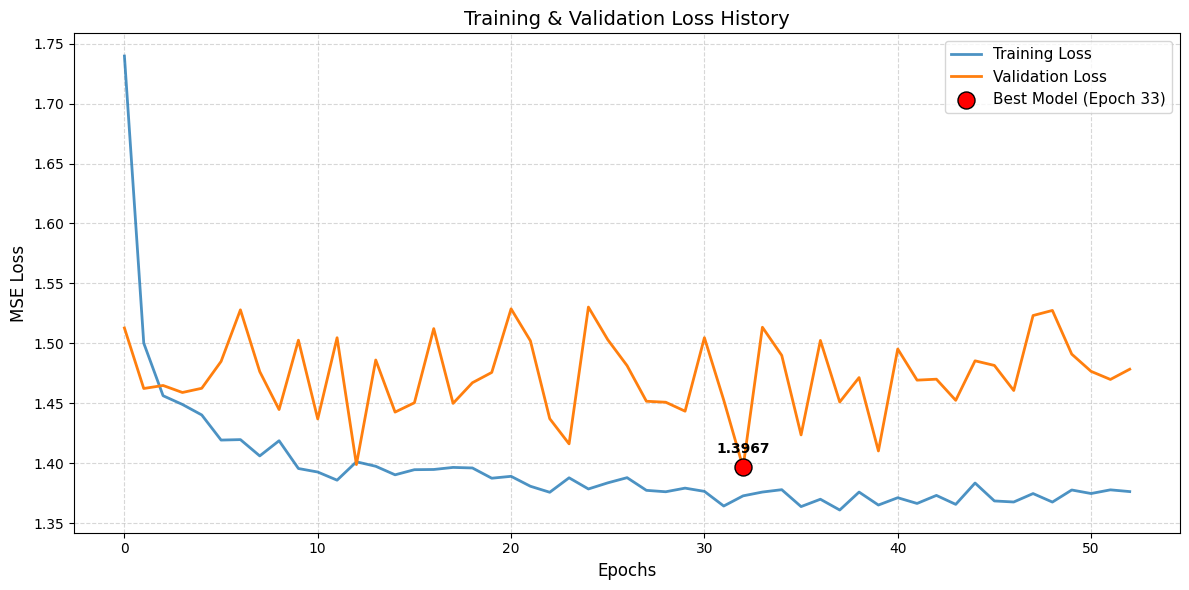

In [52]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

plt.plot(train_loss_history, label='Training Loss', color='#1f77b4', alpha=0.8, linewidth=2)
plt.plot(val_loss_history, label='Validation Loss', color='#ff7f0e', linewidth=2)

if len(val_loss_history) > 0:
    min_val_loss = min(val_loss_history)
    min_epoch = val_loss_history.index(min_val_loss)

    plt.scatter(min_epoch, min_val_loss, color='red', s=150, zorder=5, edgecolors='black', label=f'Best Model (Epoch {min_epoch+1})')

    plt.annotate(f'{min_val_loss:.4f}',
                 (min_epoch, min_val_loss),
                 xytext=(0, 10), textcoords='offset points', ha='center', fontsize=10, fontweight='bold')

plt.title('Training & Validation Loss History', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

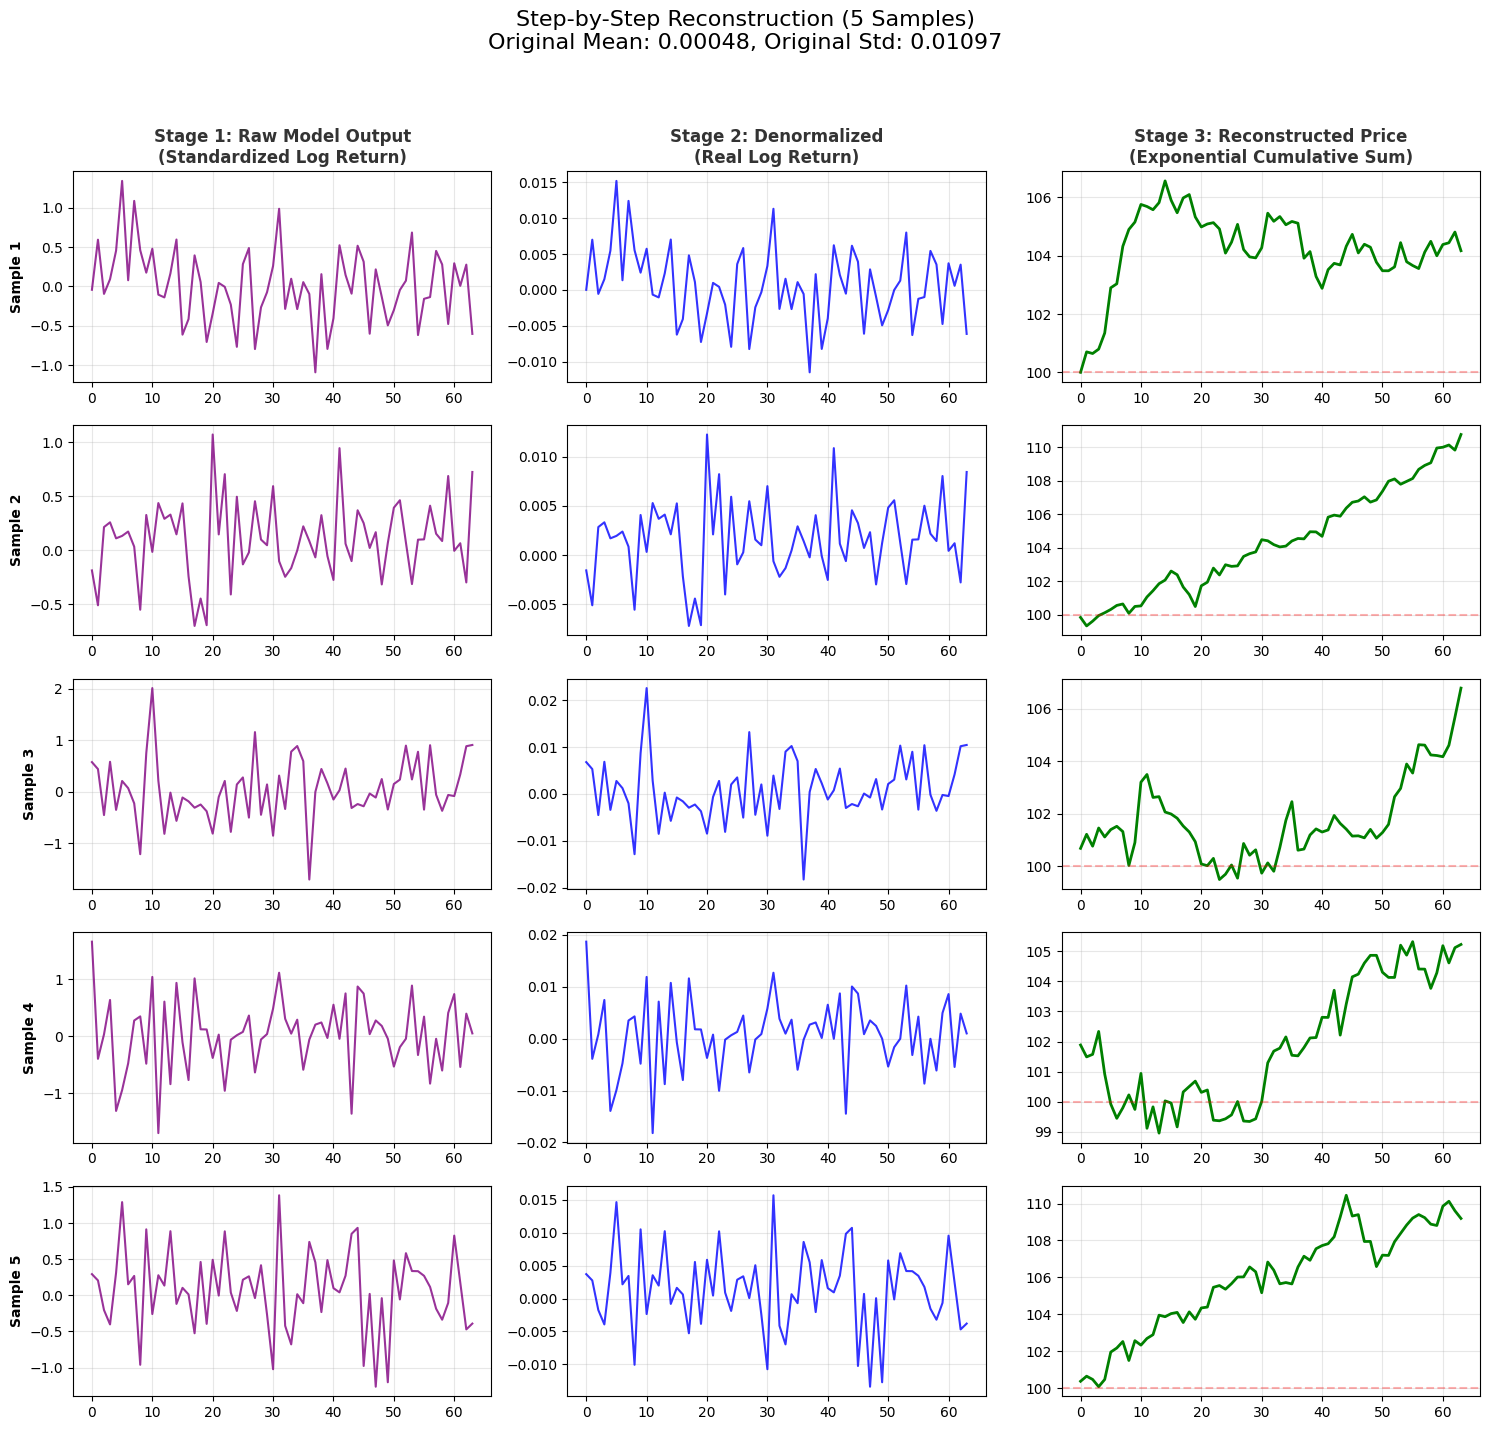

In [53]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. ODE Solver (Euler Method) for Sampling
# =========================================================
def generate_samples_step_by_step(model, n_samples=5, steps=50):
    """
    Generates synthetic data by solving the ODE: dx/dt = v(x, t)
    Uses simple Euler integration method.
    """
    # Set model to evaluation mode (turns off dropout)
    model.eval()

    # A. Initialize with Standard Gaussian Noise at t=0
    # Shape: (Batch_Size, Sequence_Length)
    x = torch.randn(n_samples, 64).to(DEVICE)

    dt = 1.0 / steps   # Step size
    current_t = 0.0

    # B. Iteratively solve the ODE from t=0 to t=1
    with torch.no_grad():
        for i in range(steps):
            # Create a time tensor for the current batch
            # Shape: (Batch_Size) -> e.g., [0.02, 0.02, ...]
            t_tensor = torch.ones(n_samples).to(DEVICE) * current_t

            # Predict velocity (direction) using the model
            # v_theta = model(x_t, t)
            velocity = model(x, t_tensor)

            # Euler Step Update: x_new = x_old + velocity * dt
            x = x + velocity * dt

            # Advance time
            current_t += dt

    # Return generated samples as numpy array
    return x.cpu().numpy()

# Generate 5 samples using 100 steps for higher quality
generated_raw = generate_samples_step_by_step(model, n_samples=5, steps=100)

# =========================================================
# 2. Step-by-Step Visualization & Reconstruction
# =========================================================

# Ensure mean and std are floats (handle if they are tensors from previous steps)
# 'train_std' and 'train_mean' must be defined from your data preprocessing step
std_val = float(train_std) if isinstance(train_std, torch.Tensor) else float(train_std)
mean_val = float(train_mean) if isinstance(train_mean, torch.Tensor) else float(train_mean)
initial_price = 100.0 # Assumed starting price

# Create a plot with 5 rows (samples) and 3 columns (stages)
fig, axes = plt.subplots(5, 3, figsize=(15, 15))
fig.suptitle(f"Step-by-Step Reconstruction (5 Samples)\nOriginal Mean: {mean_val:.5f}, Original Std: {std_val:.5f}", fontsize=16)

# Column Titles
cols = ["Stage 1: Raw Model Output\n(Standardized Log Return)",
        "Stage 2: Denormalized\n(Real Log Return)",
        "Stage 3: Reconstructed Price\n(Exponential Cumulative Sum)"]

for ax, col in zip(axes[0], cols):
    ax.set_title(col, fontweight='bold', color='#333333')

for i in range(5):
    # --- Stage 1: Raw Output (Standardized) ---
    # This is what the neural network actually generated
    raw_data = generated_raw[i]

    axes[i, 0].plot(raw_data, color='purple', alpha=0.8)
    axes[i, 0].set_ylabel(f"Sample {i+1}", fontweight='bold')
    axes[i, 0].grid(True, alpha=0.3)

    # --- Stage 2: Denormalize (Reverse Standardization) ---
    # Formula: x_real = (x_standard * std) + mean
    # We bring back the original scale of the market volatility
    denorm_data = (raw_data * std_val) + mean_val

    axes[i, 1].plot(denorm_data, color='blue', alpha=0.8)
    axes[i, 1].grid(True, alpha=0.3)

    # --- Stage 3: Price Reconstruction (Reverse Log) ---
    # Formula: Price_t = P0 * exp(cumsum(log_returns))

    # 1. Calculate cumulative sum of log returns
    cum_log_returns = np.cumsum(denorm_data)

    # 2. Apply exponential to reverse the log operation
    price_path = initial_price * np.exp(cum_log_returns)

    axes[i, 2].plot(price_path, color='green', linewidth=2)
    axes[i, 2].grid(True, alpha=0.3)

    # Add a red dashed line for the starting price
    axes[i, 2].axhline(initial_price, color='red', linestyle='--', alpha=0.3, label='Start Price')

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

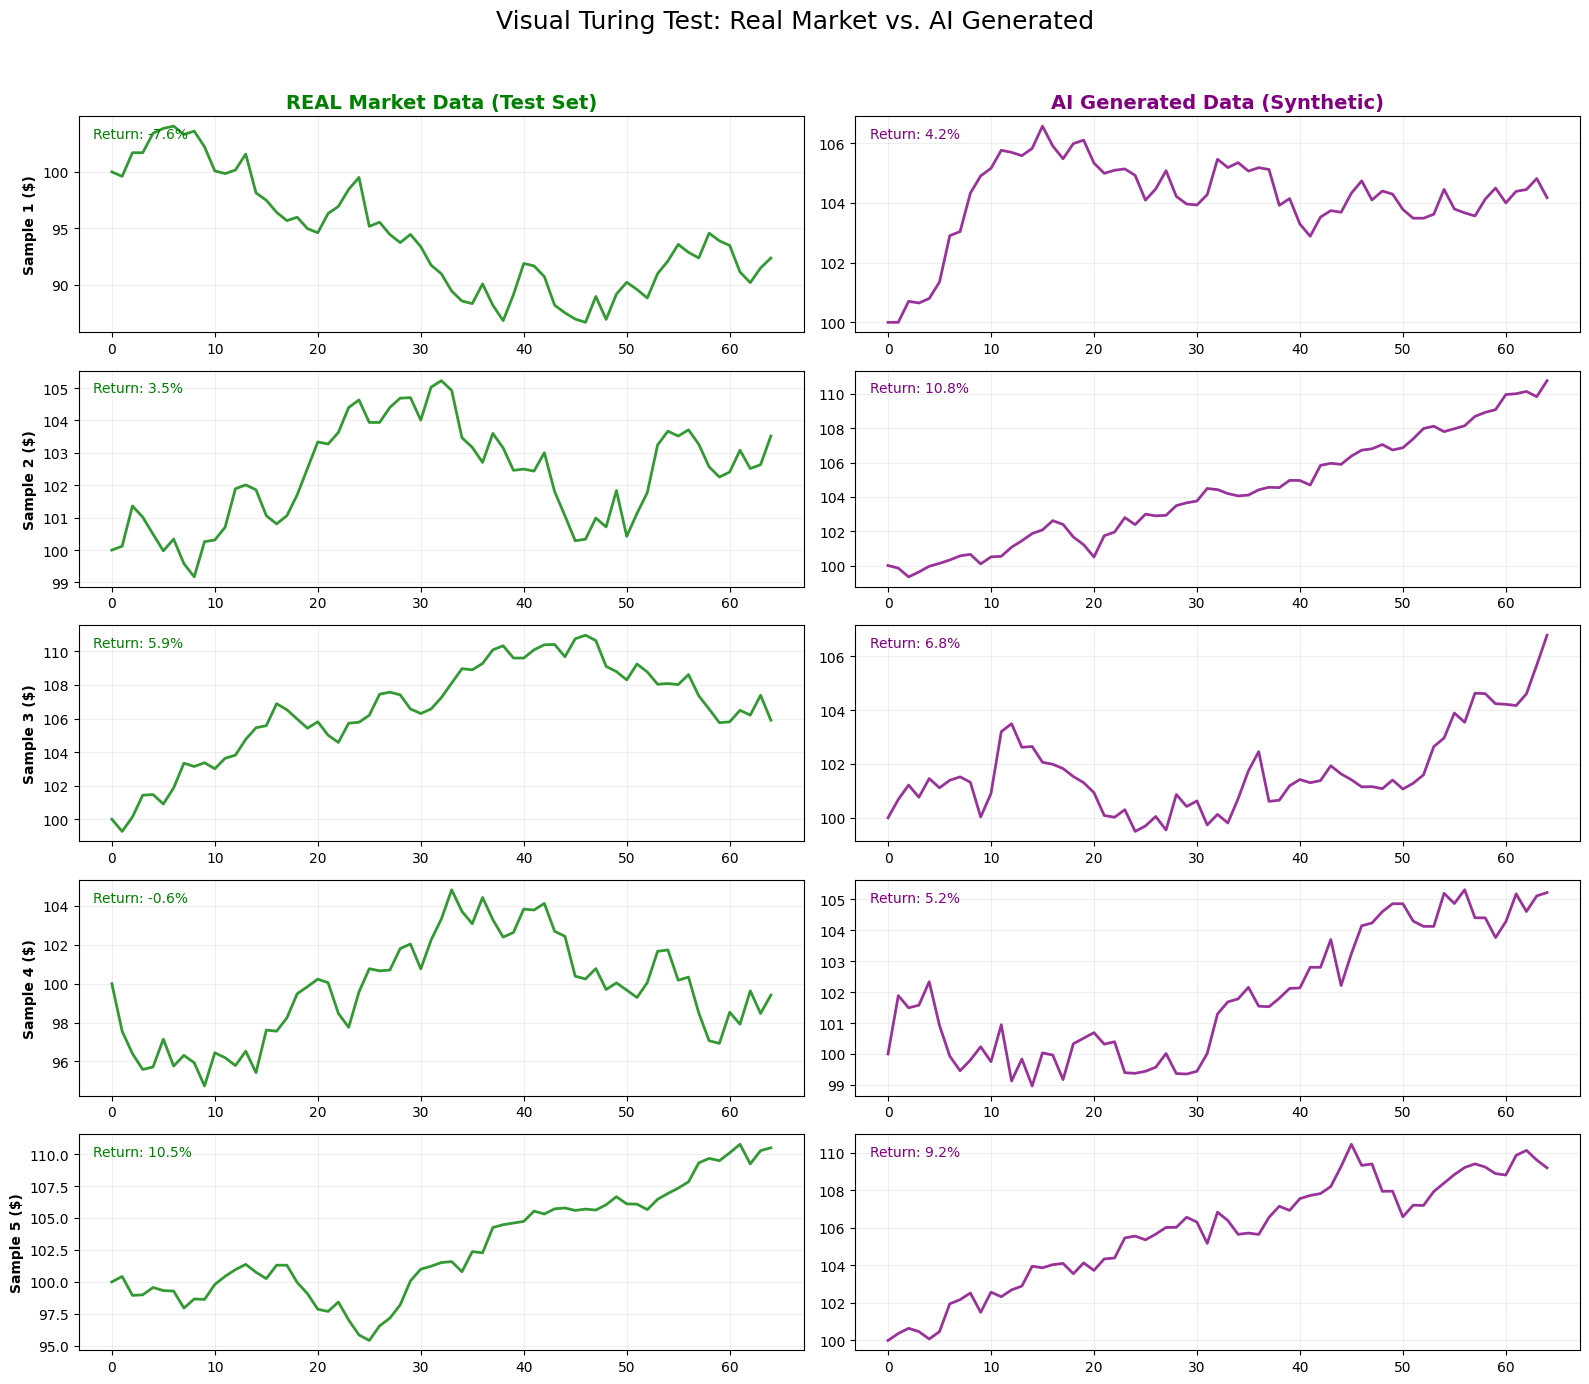

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import random

# =========================================================
# 1. Prepare Data for Comparison
# =========================================================

# A. Get 5 Random REAL samples from Test Set
# We assume 'test_windows' is your numpy array of real test data
random_indices = np.random.choice(len(test_windows), 5, replace=False)
real_samples_raw = test_windows[random_indices]

# B. Get 5 GENERATED samples (from previous step)
# We assume 'generated_raw' is available from the previous code block
# If you generated more than 5, we take the first 5
gen_samples_raw = generated_raw[:5]

# C. Helper Function: Convert Log-Returns to Price Path
def convert_to_price_path(data, mean, std, start_price=100.0):
    """
    1. Denormalize: (x * std) + mean
    2. Cumulative Sum: cumsum()
    3. Exponentiate: P0 * exp(cumsum)
    """
    # Ensure mean/std are scalar floats
    s = float(std) if isinstance(std, torch.Tensor) else float(std)
    m = float(mean) if isinstance(mean, torch.Tensor) else float(mean)

    real_log_ret = (data * s) + m
    price_path = start_price * np.exp(np.cumsum(real_log_ret))

    # Insert start price at index 0 for better visualization
    return np.insert(price_path, 0, start_price)

# =========================================================
# 2. Visualization: Side-by-Side Comparison
# =========================================================

fig, axes = plt.subplots(5, 2, figsize=(16, 15))
fig.suptitle("Visual Turing Test: Real Market vs. AI Generated", fontsize=18, y=0.95)

# Column Headers
axes[0, 0].set_title("REAL Market Data (Test Set)", fontsize=14, color='green', fontweight='bold')
axes[0, 1].set_title("AI Generated Data (Synthetic)", fontsize=14, color='purple', fontweight='bold')

for i in range(5):
    # --- Left Column: REAL Data ---
    real_price = convert_to_price_path(real_samples_raw[i], mean_val, std_val)
    axes[i, 0].plot(real_price, color='green', linewidth=2, alpha=0.8)
    axes[i, 0].set_ylabel(f"Sample {i+1} ($)", fontweight='bold')
    axes[i, 0].grid(True, alpha=0.2)

    # Calculate simple return for annotation
    real_ret = (real_price[-1] - real_price[0]) / real_price[0] * 100
    axes[i, 0].text(0.02, 0.9, f"Return: {real_ret:.1f}%", transform=axes[i, 0].transAxes, color='green')

    # --- Right Column: AI Data ---
    gen_price = convert_to_price_path(gen_samples_raw[i], mean_val, std_val)
    axes[i, 1].plot(gen_price, color='purple', linewidth=2, alpha=0.8)
    axes[i, 1].grid(True, alpha=0.2)

    # Calculate simple return for annotation
    gen_ret = (gen_price[-1] - gen_price[0]) / gen_price[0] * 100
    axes[i, 1].text(0.02, 0.9, f"Return: {gen_ret:.1f}%", transform=axes[i, 1].transAxes, color='purple')

    # Match Y-axis limits for fairer comparison within the row?
    # Usually better to let them scale independently unless starting prices are vastly different.
    # Here we let them auto-scale to see the SHAPE better.

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

Total Real Samples (Train + Test): 3393
Generating 3393 synthetic samples...
Batch 10/54 done...
Batch 20/54 done...
Batch 30/54 done...
Batch 40/54 done...
Batch 50/54 done...
Generation Complete. Shape: (3393, 64)


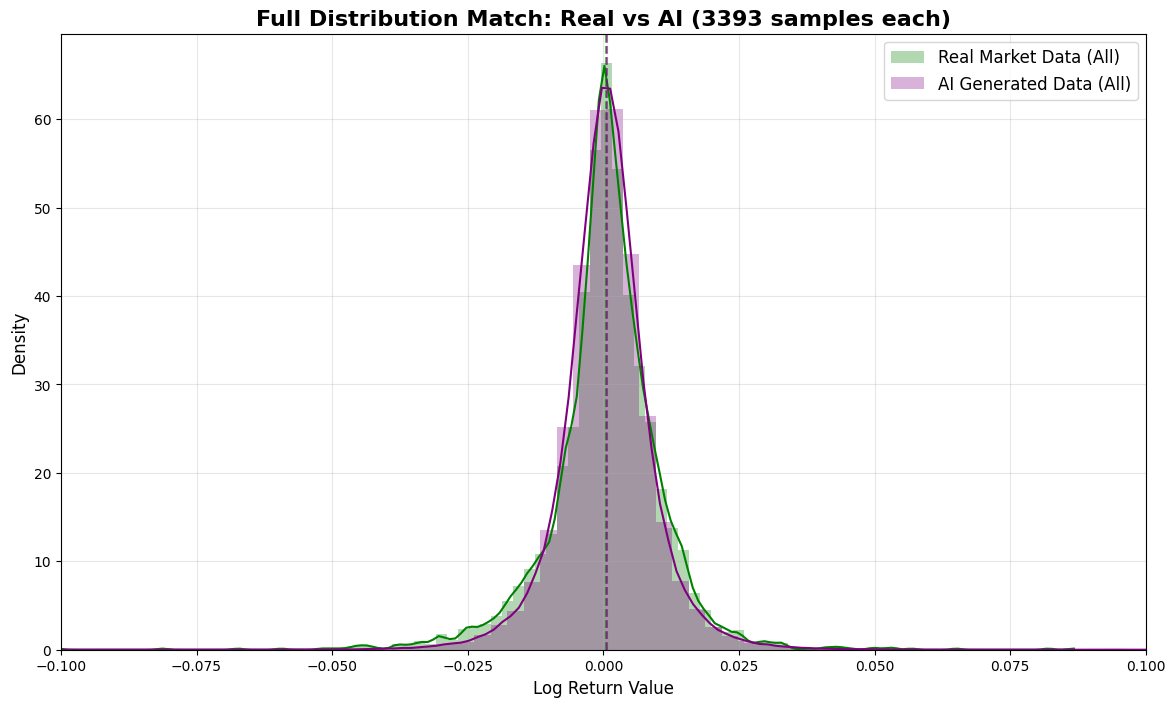


STATISTICAL COMPARISON (FULL DATASET)
Metric          | Real Data       | AI Generated    | Diff
-----------------------------------------------------------------
Mean            | 0.000483        | 0.000610        | 0.000127
Std Dev         | 0.010903        | 0.008497        | 0.002406
Skewness        | -0.728523        | -0.041160        | 0.687363
Kurtosis        | 12.036161        | 7.902679        | 4.133482


In [62]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis, skew

# =========================================================
# 1. Prepare ALL Real Data
# =========================================================
all_real_data = np.concatenate([train_windows, test_windows], axis=0)
n_total_samples = len(all_real_data)

print(f"Total Real Samples (Train + Test): {n_total_samples}")

# =========================================================
# 2. Generate EXACTLY the same amount of Synthetic Data
# =========================================================
print(f"Generating {n_total_samples} synthetic samples...")

model.eval()
generated_all = []
batch_size = 64

num_batches = int(np.ceil(n_total_samples / batch_size))

with torch.no_grad():
    for b in range(num_batches):
        current_bs = min(batch_size, n_total_samples - len(generated_all) * batch_size)
        if current_bs <= 0: break

        x = torch.randn(current_bs, 64).to(DEVICE)

        dt = 1.0 / 50
        curr_t = 0.0
        for i in range(50):
            t_tensor = torch.ones(current_bs).to(DEVICE) * curr_t
            velocity = model(x, t_tensor)
            x = x + velocity * dt
            curr_t += dt

        generated_all.append(x.cpu().numpy())

        if (b+1) % 10 == 0:
            print(f"Batch {b+1}/{num_batches} done...")


generated_all = np.concatenate(generated_all, axis=0)

generated_all = generated_all[:n_total_samples]

print(f"Generation Complete. Shape: {generated_all.shape}")

# =========================================================
# 3. Denormalize & Flatten for Statistics
# =========================================================

s_val = float(train_std) if isinstance(train_std, torch.Tensor) else float(train_std)
m_val = float(train_mean) if isinstance(train_mean, torch.Tensor) else float(train_mean)

real_flat = (all_real_data.flatten() * s_val) + m_val
fake_flat = (generated_all.flatten() * s_val) + m_val

# =========================================================
# 4. Visualization (The Big Histogram)
# =========================================================
plt.figure(figsize=(14, 8))

sns.histplot(real_flat, kde=True, stat="density", bins=100,
             color="green", element="step", label='Real Market Data (All)', alpha=0.3, linewidth=0)


sns.histplot(fake_flat, kde=True, stat="density", bins=100,
             color="purple", element="step", label='AI Generated Data (All)', alpha=0.3, linewidth=0)

plt.axvline(np.mean(real_flat), color='green', linestyle='--', alpha=0.6)
plt.axvline(np.mean(fake_flat), color='purple', linestyle='--', alpha=0.6)

plt.title(f"Full Distribution Match: Real vs AI ({n_total_samples} samples each)", fontsize=16, fontweight='bold')
plt.xlabel("Log Return Value", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(fontsize=12)
plt.xlim(-0.10, 0.10)
plt.grid(True, alpha=0.3)
plt.show()

# =========================================================
# 5. Final Statistical Report
# =========================================================
print("\n" + "="*50)
print("STATISTICAL COMPARISON (FULL DATASET)")
print("="*50)
print(f"{'Metric':<15} | {'Real Data':<15} | {'AI Generated':<15} | {'Diff'}")
print("-" * 65)

metrics = {
    "Mean": (np.mean(real_flat), np.mean(fake_flat)),
    "Std Dev": (np.std(real_flat), np.std(fake_flat)),
    "Skewness": (skew(real_flat), skew(fake_flat)),
    "Kurtosis": (kurtosis(real_flat), kurtosis(fake_flat))
}

for name, (real, fake) in metrics.items():
    diff = abs(real - fake)
    print(f"{name:<15} | {real:.6f}        | {fake:.6f}        | {diff:.6f}")
print("="*50)

Generating synthetic data for volatility analysis...
VOLATILITY STATISTICS
Metric               | Real Data       | AI Generated   
------------------------------------------------------------
Mean Volatility      | 0.010095        | 0.007900
Max Volatility       | 0.016966        | 0.024775
Min Volatility       | 0.006363        | 0.003782


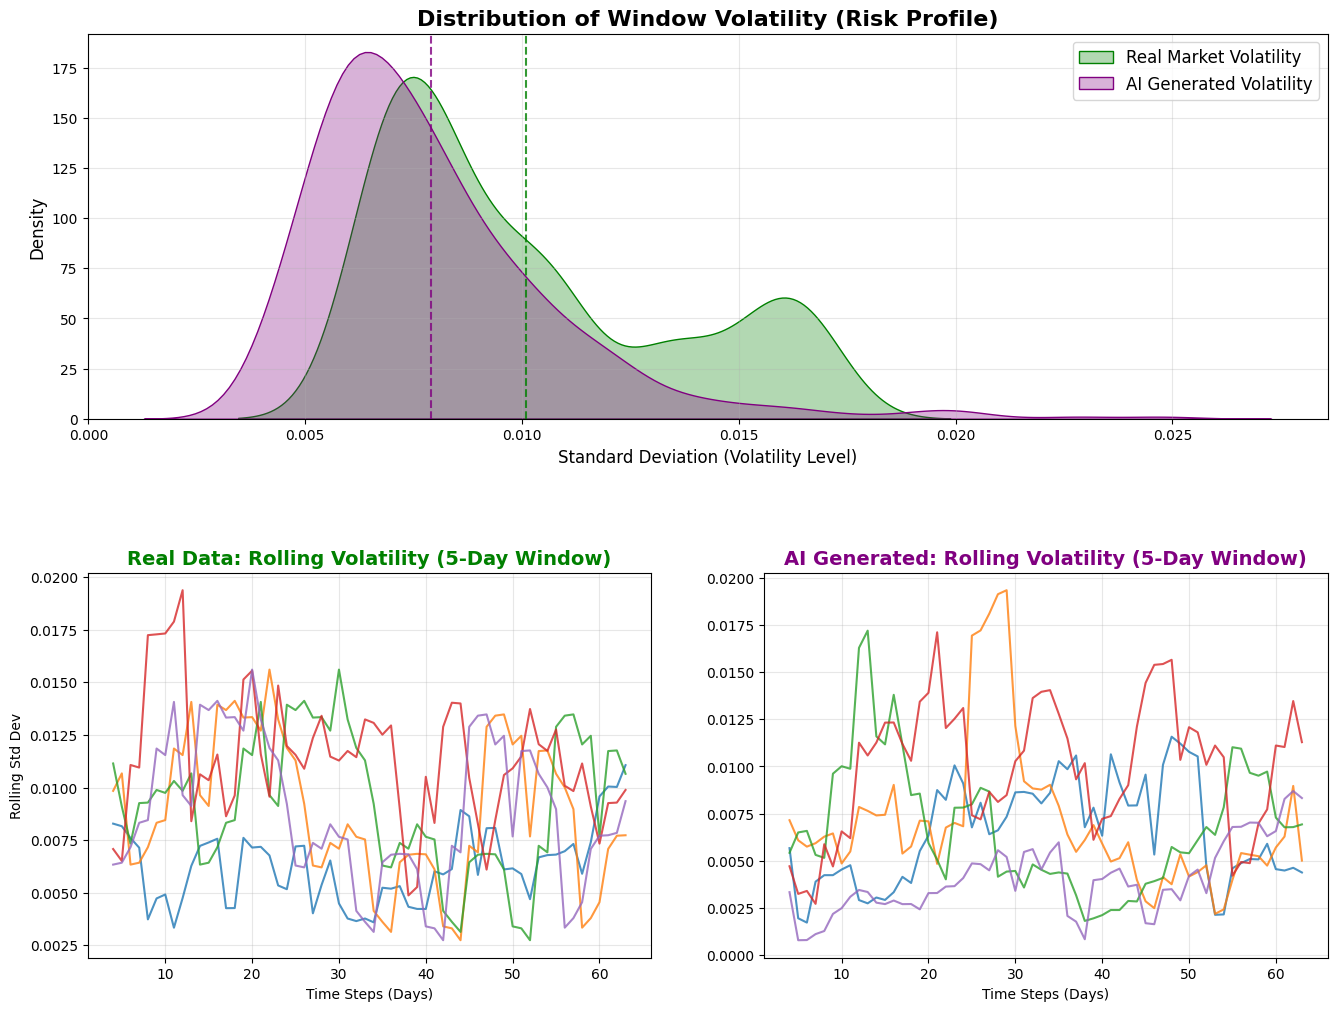

In [63]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================
# 1. Data Generation (Synthetic Sampling)
# =========================================================
print("Generating synthetic data for volatility analysis...")

# Define number of samples to generate for robust statistics
N_SAMPLES = 500
BATCH_SIZE = 64

# Container for generated data
generated_data = []
model.eval()

# Calculate batches
num_batches = int(np.ceil(N_SAMPLES / BATCH_SIZE))

with torch.no_grad():
    for b in range(num_batches):
        # Determine current batch size
        current_bs = min(BATCH_SIZE, N_SAMPLES - len(generated_data) * BATCH_SIZE)
        if current_bs <= 0: break

        # A. Start from Standard Gaussian Noise (t=0)
        x = torch.randn(current_bs, 64).to(DEVICE)

        # B. Solve ODE (Euler Method) from t=0 to t=1
        dt = 1.0 / 50 # 50 steps
        curr_t = 0.0

        for i in range(50):
            # Time embedding/channel setup
            t_tensor = torch.ones(current_bs).to(DEVICE) * curr_t

            # Predict velocity
            velocity = model(x, t_tensor)

            # Update state
            x = x + velocity * dt
            curr_t += dt

        # Store results
        generated_data.append(x.cpu().numpy())

# Concatenate all batches into a single numpy array
# Shape: (N_SAMPLES, 64)
generated_data = np.concatenate(generated_data, axis=0)[:N_SAMPLES]

# =========================================================
# 2. Data Preparation & Denormalization
# =========================================================
# Get Real Data (Test Set)
# We take the same number of samples from the test set for fair comparison
indices = np.random.choice(len(test_windows), N_SAMPLES, replace=True)
real_data = test_windows[indices]

# Denormalize Data: Convert back to Real Log-Returns
# Formula: real = (normalized * std) + mean
# (Using scalar float values for mean/std)
s_val = float(train_std) if isinstance(train_std, torch.Tensor) else float(train_std)
m_val = float(train_mean) if isinstance(train_mean, torch.Tensor) else float(train_mean)

real_returns = (real_data * s_val) + m_val
fake_returns = (generated_data * s_val) + m_val

# =========================================================
# 3. Volatility Calculation
# =========================================================

# --- Metric A: Window Volatility Distribution ---
# Calculate the Standard Deviation (Volatility) for EACH 64-day window
# This tells us: "How volatile is this specific period?"
real_window_vol = np.std(real_returns, axis=1)
fake_window_vol = np.std(fake_returns, axis=1)

# --- Metric B: Rolling Volatility Paths (Dynamic) ---
# We select 5 random samples to visualize how volatility changes over time
# Window size for rolling calculation = 5 days
ROLLING_WINDOW = 5

def get_rolling_vol(data_array):
    # Converts (64,) array to pandas Series and calculates rolling std
    return pd.Series(data_array).rolling(window=ROLLING_WINDOW).std().values

# =========================================================
# 4. Visualization
# =========================================================
fig = plt.figure(figsize=(16, 12))
plt.subplots_adjust(hspace=0.4)

# --- Plot 1: Volatility Distribution (KDE) ---
# Compares the frequency of High-Vol vs Low-Vol periods
ax1 = plt.subplot(2, 1, 1)
sns.kdeplot(real_window_vol, fill=True, color='green', label='Real Market Volatility', alpha=0.3)
sns.kdeplot(fake_window_vol, fill=True, color='purple', label='AI Generated Volatility', alpha=0.3)

# Add mean lines
plt.axvline(np.mean(real_window_vol), color='green', linestyle='--', alpha=0.8)
plt.axvline(np.mean(fake_window_vol), color='purple', linestyle='--', alpha=0.8)

ax1.set_title("Distribution of Window Volatility (Risk Profile)", fontsize=16, fontweight='bold')
ax1.set_xlabel("Standard Deviation (Volatility Level)", fontsize=12)
ax1.set_ylabel("Density", fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# --- Plot 2: Rolling Volatility Dynamics (Side-by-Side) ---
# Visualizing 5 samples to see volatility clustering
ax2 = plt.subplot(2, 2, 3) # Real
ax3 = plt.subplot(2, 2, 4) # AI

# Plot 5 Real Samples
for i in range(5):
    vol_path = get_rolling_vol(real_returns[i])
    ax2.plot(vol_path, label=f'Sample {i+1}', alpha=0.8)

ax2.set_title("Real Data: Rolling Volatility (5-Day Window)", fontsize=14, color='green', fontweight='bold')
ax2.set_xlabel("Time Steps (Days)")
ax2.set_ylabel("Rolling Std Dev")
ax2.grid(True, alpha=0.3)

# Plot 5 AI Generated Samples
for i in range(5):
    vol_path = get_rolling_vol(fake_returns[i])
    ax3.plot(vol_path, label=f'Sample {i+1}', alpha=0.8)

ax3.set_title("AI Generated: Rolling Volatility (5-Day Window)", fontsize=14, color='purple', fontweight='bold')
ax3.set_xlabel("Time Steps (Days)")
ax3.grid(True, alpha=0.3)

# --- Statistics Printout ---
print("="*50)
print("VOLATILITY STATISTICS")
print("="*50)
print(f"{'Metric':<20} | {'Real Data':<15} | {'AI Generated':<15}")
print("-" * 60)
print(f"{'Mean Volatility':<20} | {np.mean(real_window_vol):.6f}        | {np.mean(fake_window_vol):.6f}")
print(f"{'Max Volatility':<20} | {np.max(real_window_vol):.6f}        | {np.max(fake_window_vol):.6f}")
print(f"{'Min Volatility':<20} | {np.min(real_window_vol):.6f}        | {np.min(fake_window_vol):.6f}")
print("="*50)

plt.show()

Calculating Advanced Metrics (SWD & Autocorrelation)...


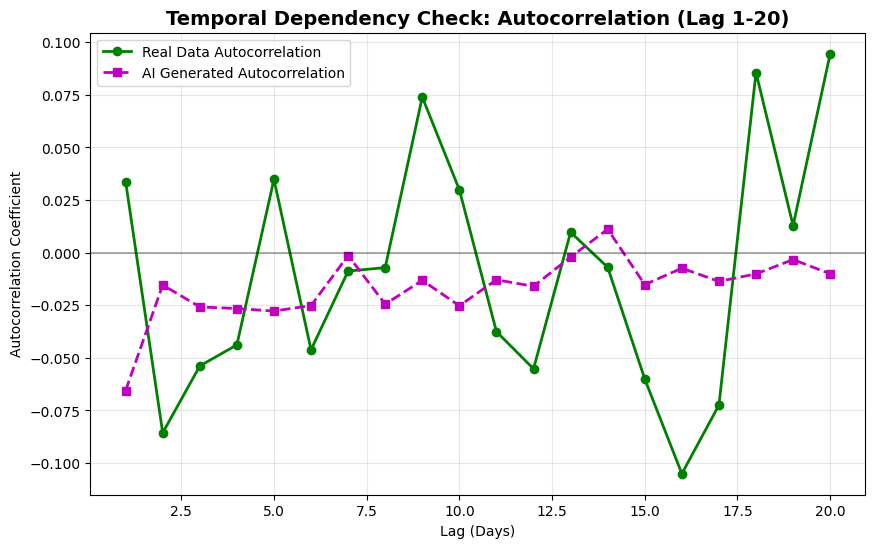


FINAL EVALUATION REPORT (Temporal & Structural)
1. Sliced Wasserstein Distance (SWD):  0.000008
   (Lower is better. Measures shape similarity)
------------------------------------------------------------
2. Autocorrelation MSE:                0.003460
   (Lower is better. Measures temporal memory match)


In [64]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.stats import wasserstein_distance

# =========================================================
# 1. Helper Function: Sliced Wasserstein Distance (SWD)
# =========================================================
def sliced_wasserstein_distance(real_data, fake_data, num_projections=1000, device='cpu'):
    """
    Calculates Sliced Wasserstein Distance between two distributions.
    It projects high-dim data onto random vectors and calculates 1D Wasserstein distance.
    """
    # Convert to tensors if they are numpy arrays
    if isinstance(real_data, np.ndarray):
        real_data = torch.from_numpy(real_data).float()
    if isinstance(fake_data, np.ndarray):
        fake_data = torch.from_numpy(fake_data).float()

    batch_size, seq_len = real_data.shape

    # 1. Generate random projections (slices)
    # Shape: (Seq_Len, Num_Projections)
    projections = torch.randn((seq_len, num_projections)).to(device)

    # Normalize projections to unit length
    projections = projections / torch.norm(projections, dim=0)

    # 2. Project data onto lines
    # Shape: (Batch_Size, Num_Projections)
    projected_real = torch.matmul(real_data.to(device), projections)
    projected_fake = torch.matmul(fake_data.to(device), projections)

    # 3. Sort projections (sorting 1D data is key for Wasserstein)
    sorted_real, _ = torch.sort(projected_real, dim=0)
    sorted_fake, _ = torch.sort(projected_fake, dim=0)

    # 4. Calculate L2 distance between sorted projections (Wasserstein-2)
    diff = sorted_real - sorted_fake
    swd = torch.mean(torch.pow(diff, 2))

    return swd.item()

# =========================================================
# 2. Helper Function: Autocorrelation Analysis
# =========================================================
def calculate_autocorrelation(data_array, max_lag=20):
    """
    Calculates the mean autocorrelation for each lag across all samples.
    data_array shape: (N_Samples, Sequence_Length)
    """
    n_samples, seq_len = data_array.shape
    acf_mean = []

    # Iterate through lags (1 to max_lag)
    for lag in range(1, max_lag + 1):
        correlations = []
        for i in range(n_samples):
            series = data_array[i]
            # Calculate correlation between x[t] and x[t-lag]
            if np.std(series) < 1e-6: # Avoid division by zero for flat lines
                corr = 0
            else:
                corr = np.corrcoef(series[:-lag], series[lag:])[0, 1]

            if not np.isnan(corr):
                correlations.append(corr)

        # Average correlation for this lag across all samples
        acf_mean.append(np.mean(correlations))

    return np.array(acf_mean)

# =========================================================
# 3. Execution & Calculation
# =========================================================
# Ensure we define the data inputs (Denormalized data from previous step)
# real_returns: (N, 64) numpy array
# fake_returns: (N, 64) numpy array
print("Calculating Advanced Metrics (SWD & Autocorrelation)...")

# --- A. Calculate SWD ---
swd_score = sliced_wasserstein_distance(real_returns, fake_returns, num_projections=1000, device=DEVICE)

# --- B. Calculate Autocorrelation ---
MAX_LAG = 20
real_acf = calculate_autocorrelation(real_returns, max_lag=MAX_LAG)
fake_acf = calculate_autocorrelation(fake_returns, max_lag=MAX_LAG)

# --- C. Calculate Autocorrelation MSE ---
# Mean Squared Error between the two ACF curves
acf_mse = np.mean((real_acf - fake_acf) ** 2)

# =========================================================
# 4. Visualization & Report
# =========================================================
plt.figure(figsize=(10, 6))

# Plot Real ACF
plt.plot(range(1, MAX_LAG + 1), real_acf, 'g-o', label='Real Data Autocorrelation', linewidth=2)

# Plot Fake ACF
plt.plot(range(1, MAX_LAG + 1), fake_acf, 'm--s', label='AI Generated Autocorrelation', linewidth=2)

plt.axhline(0, color='black', linestyle='-', alpha=0.3)
plt.title(f"Temporal Dependency Check: Autocorrelation (Lag 1-{MAX_LAG})", fontsize=14, fontweight='bold')
plt.xlabel("Lag (Days)")
plt.ylabel("Autocorrelation Coefficient")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print Final Score Card
print("\n" + "="*60)
print("FINAL EVALUATION REPORT (Temporal & Structural)")
print("="*60)
print(f"1. Sliced Wasserstein Distance (SWD):  {swd_score:.6f}")
print("   (Lower is better. Measures shape similarity)")
print("-" * 60)
print(f"2. Autocorrelation MSE:                {acf_mse:.6f}")
print("   (Lower is better. Measures temporal memory match)")
print("="*60)